In [2]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

np.random.seed(42)

In [3]:
with open('pocket_rmscore_matrix_v2_avg.pkl', 'rb') as f:
    rmscore_matrix = pickle.load(f)

rmscore_matrix.keys()

dict_keys(['rmscore_matrix', 'pocket_names', 'pocket_files', 'n_pockets'])

In [4]:
print(rmscore_matrix['rmscore_matrix'][0][:5])
print(f'Shape: {rmscore_matrix["rmscore_matrix"].shape}')

[1.       0.72052  0.22271  0.391525 0.473265]
Shape: (1192, 1192)


In [5]:
print(rmscore_matrix['pocket_names'][:5])
print(len(rmscore_matrix['pocket_names']))

['1aju_A', '1akx_A', '1am0_A', '1arj_N', '1eht_A']
1192


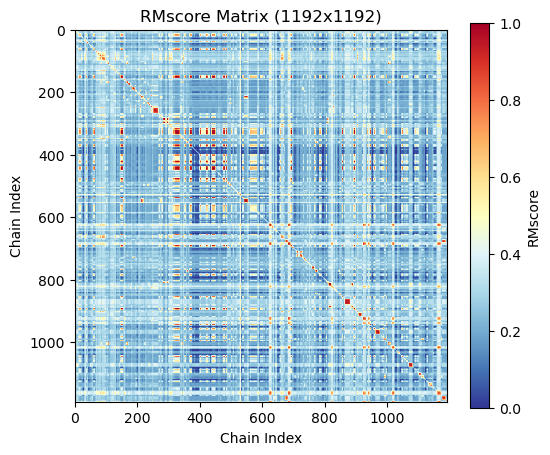

In [6]:
# RMScore Matrix Heatmap
similarity_matrix = rmscore_matrix['rmscore_matrix']
n_chains = len(rmscore_matrix['pocket_names'])

plt.figure(figsize=(6, 5))
plt.imshow(similarity_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
plt.colorbar(label='RMscore')
plt.title(f'RMscore Matrix ({n_chains}x{n_chains})')
plt.xlabel('Chain Index')
plt.ylabel('Chain Index')
plt.show()

RMscore cutoff: 0.75
Number of folds: 5


Loaded 1192 pocket names with RNA sequences
Unique RNA sequences: 376
Sequences shared by multiple pockets: 191

Cluster merging for RNA sequence constraint:
  Original clusters: 402
  Merges performed: 210
  Merged clusters: 194

Total samples: 1192
Number of merged clusters: 194
Target per fold: 238
Largest merged cluster: 248 samples

Fold sizes: [248, 236, 236, 236, 236]
Std dev: 4.80


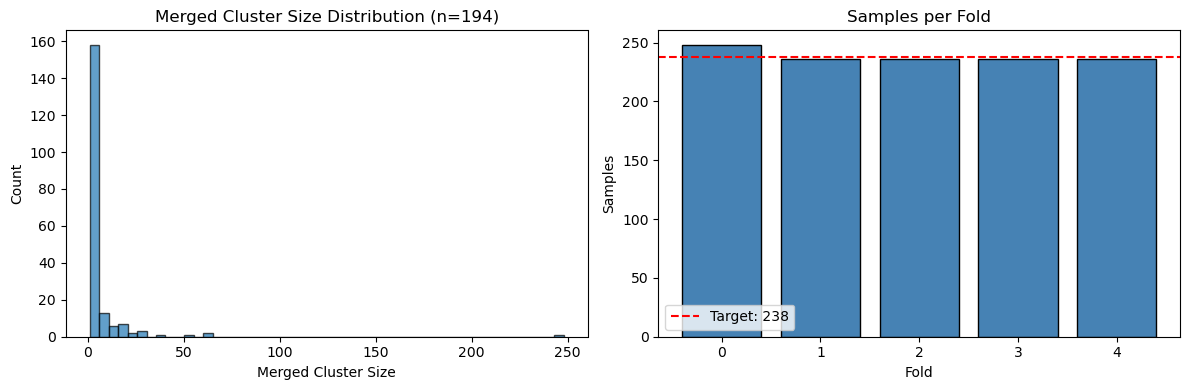

In [7]:
"""
5-Fold Split by RNA Structure Similarity (RMscore)

Logic (following RNAmigos2 splitting scheme):
1. Cluster chains by RMscore similarity using AgglomerativeClustering
   - metric='precomputed', linkage='single', distance_threshold=0.25 (RMscore >= 0.75)
   - Same cluster = same fold (no data leakage)
2. Additional constraint: chains with identical rna_chain_sequence must be in the same fold
3. Greedy assignment for balanced fold sizes
"""
from collections import defaultdict

# ============== Parameters ==============
CUTOFF = 0.75           # RMscore similarity threshold
N_FOLDS = 5             # Number of folds
MAX_IMBALANCE = 1.10    # Max allowed fold size (110% of target)

print(f'RMscore cutoff: {CUTOFF}')
print(f'Number of folds: {N_FOLDS}')

# ============== Step 0: Load data to get RNA sequences per chain ==============
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data_original = pickle.load(f)

# Build: pocket_name -> set of rna_chain_sequences
pocket_to_seqs = defaultdict(set)
for rna_key, rna_data in data_original.items():
    for complex_key, sample_data in rna_data.items():
        pocket_name = '_'.join(complex_key.split('_')[:2])
        pocket_to_seqs[pocket_name].add(sample_data['rna_chain_sequence'])

# Build: rna_chain_sequence -> set of pocket_names
seq_to_pockets = defaultdict(set)
for pocket_name, seqs in pocket_to_seqs.items():
    for seq in seqs:
        seq_to_pockets[seq].add(pocket_name)

print(f'Loaded {len(pocket_to_seqs)} pocket names with RNA sequences')
print(f'Unique RNA sequences: {len(seq_to_pockets)}')
# Sequences shared by multiple pockets
multi_pocket_seqs = {s: p for s, p in seq_to_pockets.items() if len(p) > 1}
print(f'Sequences shared by multiple pockets: {len(multi_pocket_seqs)}')

# ============== Step 1: AgglomerativeClustering (RNAmigos2 style) ==============
distance_matrix = 1.0 - rmscore_matrix['rmscore_matrix']

clustering = AgglomerativeClustering(
    metric='precomputed',
    n_clusters=None,
    compute_full_tree=True,
    linkage='single',
    distance_threshold=1.0 - CUTOFF  # 0.25
).fit(distance_matrix)

cluster_labels = clustering.labels_

cluster_df = pd.DataFrame({
    'pocket_name': rmscore_matrix['pocket_names'], 
    'cluster': cluster_labels
})

pocket_to_cluster = dict(zip(cluster_df['pocket_name'], cluster_df['cluster']))

# ============== Step 2: Merge clusters sharing the same RNA sequence (Union-Find) ==============
parent = {}

def find(x):
    while parent.get(x, x) != x:
        parent[x] = parent.get(parent[x], parent[x])  # path compression
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

# For each shared RNA sequence, union all clusters of its pockets
merges_done = 0
for seq, pockets in seq_to_pockets.items():
    # Get clusters for these pockets (only those in the rmscore matrix)
    clusters_for_seq = set()
    for p in pockets:
        if p in pocket_to_cluster:
            clusters_for_seq.add(pocket_to_cluster[p])
    
    if len(clusters_for_seq) > 1:
        clusters_list = list(clusters_for_seq)
        for i in range(1, len(clusters_list)):
            union(clusters_list[0], clusters_list[i])
            merges_done += 1

# Re-label clusters based on Union-Find roots
cluster_df['merged_cluster'] = cluster_df['cluster'].apply(find)
n_original = cluster_df['cluster'].nunique()
n_merged = cluster_df['merged_cluster'].nunique()
print(f'\nCluster merging for RNA sequence constraint:')
print(f'  Original clusters: {n_original}')
print(f'  Merges performed: {merges_done}')
print(f'  Merged clusters: {n_merged}')

# ============== Step 3: Cluster Statistics (on merged clusters) ==============
cluster_sizes_dict = cluster_df.groupby('merged_cluster').size().to_dict()
total_samples = sum(cluster_sizes_dict.values())
target_per_fold = total_samples // N_FOLDS

print(f'\nTotal samples: {total_samples}')
print(f'Number of merged clusters: {len(cluster_sizes_dict)}')
print(f'Target per fold: {target_per_fold}')
print(f'Largest merged cluster: {max(cluster_sizes_dict.values())} samples')

# ============== Step 4: Greedy Assignment ==============
clusters_sorted = sorted(cluster_sizes_dict.keys(), 
                         key=lambda c: cluster_sizes_dict[c], reverse=True)

fold_clusters = {i: [] for i in range(N_FOLDS)}
fold_sample_counts = {i: 0 for i in range(N_FOLDS)}
max_allowed = int(target_per_fold * MAX_IMBALANCE)

for cluster_id in clusters_sorted:
    cluster_size = cluster_sizes_dict[cluster_id]
    # Assign to fold with minimum samples
    min_fold = min(fold_sample_counts, key=fold_sample_counts.get)
    fold_clusters[min_fold].append(cluster_id)
    fold_sample_counts[min_fold] += cluster_size

fold_sizes = list(fold_sample_counts.values())
print(f'\nFold sizes: {fold_sizes}')
print(f'Std dev: {np.std(fold_sizes):.2f}')

# ============== Step 5: Visualization ==============
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cluster size distribution
cluster_sizes = cluster_df['merged_cluster'].value_counts()
axes[0].hist(cluster_sizes.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Merged Cluster Size')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Merged Cluster Size Distribution (n={len(cluster_sizes)})')

# Fold size distribution
axes[1].bar(range(N_FOLDS), fold_sizes, color='steelblue', edgecolor='black')
axes[1].axhline(y=target_per_fold, color='red', linestyle='--', label=f'Target: {target_per_fold}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Samples')
axes[1].set_title('Samples per Fold')
axes[1].legend()

plt.tight_layout()
plt.show()

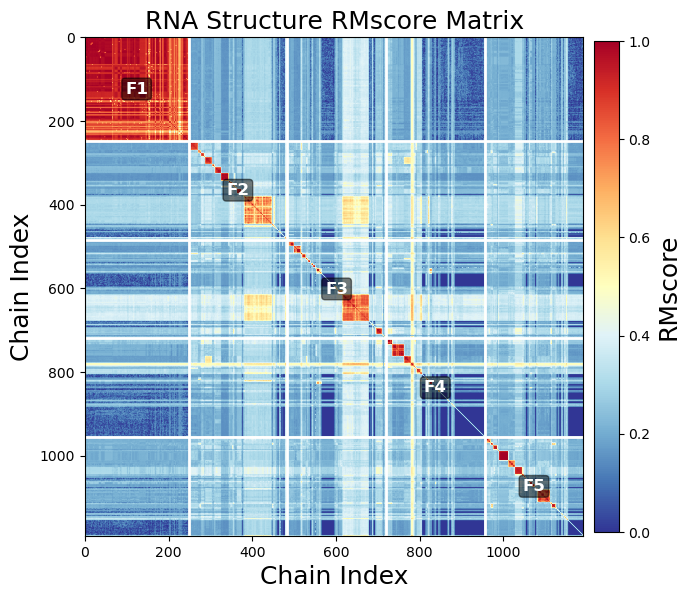

Saved: rmscore_matrix_by_fold.png/pdf


In [8]:
# ============== RMscore Matrix Heatmap (reordered by fold) ==============
# Reorder rows/columns so chains in the same fold are grouped together,
# and within each fold, sort by cluster for cleaner block-diagonal structure.

pocket_to_fold_tmp = {}
for fold_id, clusters in fold_clusters.items():
    for pocket in cluster_df[cluster_df['merged_cluster'].isin(clusters)]['pocket_name']:
        pocket_to_fold_tmp[pocket] = fold_id

pocket_names_list = list(rmscore_matrix['pocket_names'])
fold_of_each = [pocket_to_fold_tmp[p] for p in pocket_names_list]
cluster_of_each = list(cluster_df['merged_cluster'].values)

# Sort by (fold, cluster) for block-diagonal structure
sorted_indices = sorted(range(len(pocket_names_list)),
                        key=lambda i: (fold_of_each[i], cluster_of_each[i]))
sorted_folds = [fold_of_each[i] for i in sorted_indices]

# Reorder similarity matrix
reordered_matrix = similarity_matrix[np.ix_(sorted_indices, sorted_indices)]

# Find fold boundaries
fold_boundaries = []
for f in range(N_FOLDS):
    fold_start = sorted_folds.index(f)
    fold_end = len(sorted_folds) - 1 - sorted_folds[::-1].index(f)
    fold_boundaries.append((fold_start, fold_end))

# ============== Plot ==============
fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(reordered_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='equal')
ax.set_title(f'RNA Structure RMscore Matrix', fontsize=18)
ax.set_xlabel('Chain Index', fontsize=18)
ax.set_ylabel('Chain Index', fontsize=18)
cbar = fig.colorbar(im, ax=ax, shrink=1.0, label='RMscore', pad=0.02, fraction=0.046)
cbar.set_label('RMscore', fontsize=18)

# Draw fold boundary lines and labels on diagonal blocks
for f, (start, end) in enumerate(fold_boundaries):
    if f > 0:
        ax.axhline(y=start - 0.5, color='white', linewidth=2)
        ax.axvline(x=start - 0.5, color='white', linewidth=2)
    mid = (start + end) / 2
    ax.text(mid, mid, f'F{f+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig('rmscore_matrix_by_fold.png', dpi=600, bbox_inches='tight')
# plt.savefig('rmscore_matrix_by_fold.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: rmscore_matrix_by_fold.png/pdf")

In [9]:
# Load original data
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data_original = pickle.load(f)


In [10]:
pocket_to_fold = {}
for fold_id, clusters in fold_clusters.items():
    for pocket in cluster_df[cluster_df['merged_cluster'].isin(clusters)]['pocket_name']:
        pocket_to_fold[pocket] = fold_id

# Apply split
data_split = {}
matched, unmatched = 0, 0

for rna_key, rna_data in data_original.items():
    data_split[rna_key] = {}
    for complex_key, sample_data in rna_data.items():
        pocket_name = '_'.join(complex_key.split('_')[:2])  # {pdb}_{chain}
        
        if pocket_name in pocket_to_fold:
            fold_id = pocket_to_fold[pocket_name]
            sample_data['train_split'] = [i != fold_id for i in range(N_FOLDS)]
            data_split[rna_key][complex_key] = sample_data
            matched += 1
        else:
            unmatched += 1

# Remove empty entries
data_split = {k: v for k, v in data_split.items() if v}

print(f'Matched: {matched}, Unmatched: {unmatched}')

Matched: 1246, Unmatched: 0


In [11]:
# ============== Verify & Save ==============

# Count samples per fold
fold_dist = [0] * N_FOLDS
for rna_data in data_split.values():
    for sample in rna_data.values():
        test_fold = sample['train_split'].index(False)
        fold_dist[test_fold] += 1

print(f'Final fold distribution: {fold_dist}')
print(f'Total: {sum(fold_dist)}, Std: {np.std(fold_dist):.2f}')

# Verify: same cluster -> same fold
print('\nVerifying cluster constraint...')
pocket_folds = {}
for rna_data in data_split.values():
    for complex_key, sample in rna_data.items():
        pocket = '_'.join(complex_key.split('_')[:2])
        test_fold = sample['train_split'].index(False)
        if pocket not in pocket_folds:
            pocket_folds[pocket] = set()
        pocket_folds[pocket].add(test_fold)

violations = {p: f for p, f in pocket_folds.items() if len(f) > 1}
print(f'Pocket constraint: {"PASSED" if not violations else f"FAILED ({len(violations)} violations)"}')

# Save
output_path = '../data/hariboss_5fd_by_chain_structure_no_identical.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(data_split, f)
print(f'\nSaved to: {output_path}')


Final fold distribution: [258, 259, 237, 251, 241]
Total: 1246, Std: 8.86

Verifying cluster constraint...
Pocket constraint: PASSED

Saved to: ../data/hariboss_5fd_by_chain_structure_no_identical.pkl


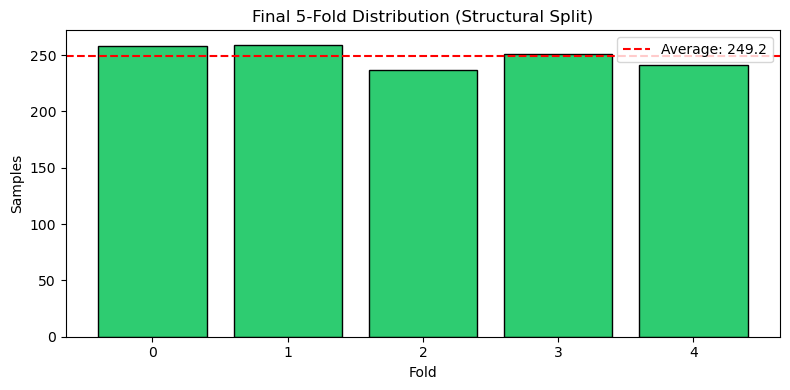

In [12]:
# Visualization of final distribution
plt.figure(figsize=(8, 4))
plt.bar(range(N_FOLDS), fold_dist, color='#2ecc71', edgecolor='black')
plt.axhline(y=sum(fold_dist)/N_FOLDS, color='red', linestyle='--', label=f'Average: {sum(fold_dist)/N_FOLDS:.1f}')
plt.xlabel('Fold')
plt.ylabel('Samples')
plt.title('Final 5-Fold Distribution (Structural Split)')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# ============== Double Check: No train-test leakage above RMscore threshold ==============
# For each fold, verify that max RMscore between any train chain and any test chain < CUTOFF

similarity_matrix = rmscore_matrix['rmscore_matrix']
pocket_names = rmscore_matrix['pocket_names']
name_to_idx = {name: idx for idx, name in enumerate(pocket_names)}

print(f"Checking train-test RMscore leakage for each fold (threshold={CUTOFF})...\n")

all_passed = True
for fold_id in range(N_FOLDS):
    # Get test and train pocket names for this fold
    test_clusters = fold_clusters[fold_id]
    test_pockets = cluster_df[cluster_df['merged_cluster'].isin(test_clusters)]['pocket_name'].tolist()
    train_pockets = cluster_df[~cluster_df['merged_cluster'].isin(test_clusters)]['pocket_name'].tolist()
    
    # Get indices
    test_idx = [name_to_idx[p] for p in test_pockets]
    train_idx = [name_to_idx[p] for p in train_pockets]
    
    # Extract pairwise RMscore between train and test
    pairwise = similarity_matrix[np.ix_(train_idx, test_idx)]
    max_score = pairwise.max()
    
    # Find violations (pairs with RMscore >= CUTOFF)
    violations = np.argwhere(pairwise >= CUTOFF)
    n_violations = len(violations)
    
    status = "PASSED" if n_violations == 0 else "FAILED"
    if n_violations > 0:
        all_passed = False
    
    print(f"Fold {fold_id}: {status} | "
          f"train={len(train_pockets)}, test={len(test_pockets)} | "
          f"max RMscore={max_score:.4f} | "
          f"violations (>={CUTOFF}): {n_violations}")
    
    # Show top violations if any
    if n_violations > 0:
        scores = [(train_pockets[i], test_pockets[j], pairwise[i, j]) 
                  for i, j in violations]
        scores.sort(key=lambda x: -x[2])
        for train_p, test_p, score in scores[:5]:
            print(f"    {train_p} <-> {test_p}: RMscore={score:.4f}")
        if n_violations > 5:
            print(f"    ... and {n_violations - 5} more")

print(f"\n{'='*50}")
print(f"Overall: {'ALL FOLDS PASSED' if all_passed else 'SOME FOLDS FAILED'}")
print(f"No train-test pair exceeds RMscore >= {CUTOFF}: {all_passed}")

Checking train-test RMscore leakage for each fold (threshold=0.75)...

Fold 0: PASSED | train=944, test=248 | max RMscore=0.5230 | violations (>=0.75): 0
Fold 1: PASSED | train=956, test=236 | max RMscore=0.7127 | violations (>=0.75): 0
Fold 2: PASSED | train=956, test=236 | max RMscore=0.7431 | violations (>=0.75): 0
Fold 3: PASSED | train=956, test=236 | max RMscore=0.7453 | violations (>=0.75): 0
Fold 4: PASSED | train=956, test=236 | max RMscore=0.7453 | violations (>=0.75): 0

Overall: ALL FOLDS PASSED
No train-test pair exceeds RMscore >= 0.75: True


In [14]:
# ============== Identify near-zero rows/columns in RMscore matrix ==============
similarity_matrix = rmscore_matrix['rmscore_matrix']
pocket_names = rmscore_matrix['pocket_names']
n = len(pocket_names)

# For each row, compute mean RMscore (excluding diagonal)
row_means = []
for i in range(n):
    scores = np.concatenate([similarity_matrix[i, :i], similarity_matrix[i, i+1:]])
    row_means.append(scores.mean())

row_means = np.array(row_means)

# Find pockets with very low mean RMscore (likely the near-zero lines)
threshold = 0.15  # mean RMscore below this
low_score_idx = np.where(row_means < threshold)[0]

print(f"Pockets with mean RMscore < {threshold} (likely the near-zero lines):")
print(f"Found {len(low_score_idx)} pockets:\n")

for idx in low_score_idx:
    max_off_diag = np.max(np.concatenate([similarity_matrix[idx, :idx], similarity_matrix[idx, idx+1:]]))
    print(f"  Index {idx:4d} | {pocket_names[idx]:40s} | mean={row_means[idx]:.4f} | max={max_off_diag:.4f}")

# Also show where they appear in the sorted matrix index
print(f"\n--- Sorted by mean RMscore (bottom 20) ---")
sorted_idx = np.argsort(row_means)
for rank, idx in enumerate(sorted_idx[:20]):
    max_off_diag = np.max(np.concatenate([similarity_matrix[idx, :idx], similarity_matrix[idx, idx+1:]]))
    print(f"  Rank {rank+1:2d} | Index {idx:4d} | {pocket_names[idx]:40s} | mean={row_means[idx]:.4f} | max={max_off_diag:.4f}")

Pockets with mean RMscore < 0.15 (likely the near-zero lines):
Found 1 pockets:

  Index  111 | 2kd4_B                                   | mean=0.1481 | max=0.5061

--- Sorted by mean RMscore (bottom 20) ---
  Rank  1 | Index  111 | 2kd4_B                                   | mean=0.1481 | max=0.5061
  Rank  2 | Index  801 | 6qzp_L5                                  | mean=0.1507 | max=0.5595
  Rank  3 | Index 1119 | 8g5z_L5                                  | mean=0.1532 | max=0.5452
  Rank  4 | Index 1118 | 8g5y_L5                                  | mean=0.1533 | max=0.6338
  Rank  5 | Index 1121 | 8g61_L5                                  | mean=0.1537 | max=0.5461
  Rank  6 | Index  859 | 6y6x_L5                                  | mean=0.1541 | max=0.5726
  Rank  7 | Index 1122 | 8g6j_L5                                  | mean=0.1546 | max=0.5453
  Rank  8 | Index 1120 | 8g60_L5                                  | mean=0.1550 | max=0.5476
  Rank  9 | Index 1021 | 7ucj_5                 

In [15]:
# ============== Check: Identical RNA sequences across different folds ==============
from collections import defaultdict

# Collect RNA sequences per fold
fold_rna_seqs = defaultdict(dict)  # fold_id -> {rna_key: rna_sequence}

for rna_key, rna_data in data_split.items():
    for complex_key, sample_data in rna_data.items():
        test_fold = sample_data['train_split'].index(False)
        # rna_key is the RNA identifier; get the actual sequence if available
        if rna_key not in fold_rna_seqs[test_fold]:
            fold_rna_seqs[test_fold][rna_key] = set()
        fold_rna_seqs[test_fold][rna_key].add(complex_key)

# For each pair of folds, find shared RNA keys
print("="*80)
print("Check: Identical RNA sequences (same rna_key) appearing in different folds")
print("="*80)

# Build: rna_key -> set of folds it appears in
rna_to_folds = defaultdict(set)
for fold_id, rna_dict in fold_rna_seqs.items():
    for rna_key in rna_dict:
        rna_to_folds[rna_key].add(fold_id)

# Find RNA keys that appear in more than one fold
shared_rnas = {rna_key: folds for rna_key, folds in rna_to_folds.items() if len(folds) > 1}

print(f"\nTotal unique RNA keys: {len(rna_to_folds)}")
print(f"RNA keys appearing in multiple folds: {len(shared_rnas)}")

if shared_rnas:
    print(f"\n{'RNA Key':<60s} | Folds")
    print("-"*80)
    for rna_key, folds in sorted(shared_rnas.items(), key=lambda x: -len(x[1])):
        fold_str = ', '.join([str(f) for f in sorted(folds)])
        print(f"{str(rna_key):<60s} | {fold_str}")
else:
    print("\nNo RNA key appears in more than one fold. All clean!")

# Also check by actual RNA sequence content if available in the data
print(f"\n{'='*80}")
print("Check: Identical RNA *sequences* across folds (same sequence, possibly different rna_key)")
print("="*80)

# Collect actual sequences per fold
fold_seq_to_rnakeys = defaultdict(lambda: defaultdict(set))  # fold -> seq -> set of rna_keys

for rna_key, rna_data in data_split.items():
    for complex_key, sample_data in rna_data.items():
        test_fold = sample_data['train_split'].index(False)
        # Try to get the actual RNA sequence
        if 'rna_seq' in sample_data:
            seq = sample_data['rna_seq']
        elif 'sequence' in sample_data:
            seq = sample_data['sequence']
        else:
            seq = rna_key  # fallback to key
        fold_seq_to_rnakeys[test_fold][seq].add(rna_key)

# Build: sequence -> {fold: set of rna_keys}
seq_to_fold_info = defaultdict(dict)
for fold_id, seq_dict in fold_seq_to_rnakeys.items():
    for seq, rna_keys in seq_dict.items():
        seq_to_fold_info[seq][fold_id] = rna_keys

shared_seqs = {seq: info for seq, info in seq_to_fold_info.items() if len(info) > 1}

print(f"\nTotal unique sequences: {len(seq_to_fold_info)}")
print(f"Sequences appearing in multiple folds: {len(shared_seqs)}")

if shared_seqs:
    print(f"\n{'Sequence (first 80 chars)':<80s} | Folds | RNA Keys")
    print("-"*120)
    for seq, fold_info in sorted(shared_seqs.items(), key=lambda x: -len(x[1])):
        fold_str = ', '.join([str(f) for f in sorted(fold_info.keys())])
        all_keys = set()
        for keys in fold_info.values():
            all_keys.update(keys)
        keys_str = ', '.join([str(k) for k in sorted(all_keys)])
        print(f"{str(seq)[:80]:<80s} | {fold_str:<6s} | {keys_str}")
else:
    print("\nNo identical sequences found across folds.")

Check: Identical RNA sequences (same rna_key) appearing in different folds

Total unique RNA keys: 862
RNA keys appearing in multiple folds: 47

RNA Key                                                      | Folds
--------------------------------------------------------------------------------
5ibb                                                         | 0, 1, 4
5ndv                                                         | 0, 3, 4
5ndw                                                         | 0, 3, 4
4f8u                                                         | 1, 4
4w29                                                         | 0, 4
4wt8                                                         | 0, 4
5ndg                                                         | 0, 4
5obm                                                         | 0, 4
6cfk                                                         | 2, 4
6cfl                                                         | 2, 4
8fc4            

In [16]:
# ============== Diagnose: Why do 72 RNA keys appear in multiple folds? ==============
from collections import defaultdict

print("="*100)
print("Root cause: Same PDB has multiple chains assigned to different folds")
print("="*100)

# For each shared rna_key, show which chains are in which fold
rna_to_chains_per_fold = defaultdict(lambda: defaultdict(list))

for rna_key, rna_data in data_split.items():
    for complex_key, sample_data in rna_data.items():
        pocket_name = '_'.join(complex_key.split('_')[:2])  # {pdb}_{chain}
        test_fold = sample_data['train_split'].index(False)
        rna_to_chains_per_fold[rna_key][test_fold].append(pocket_name)

# Only show PDBs in multiple folds
shared_rna_keys = {k: v for k, v in rna_to_chains_per_fold.items() if len(v) > 1}

print(f"\n{len(shared_rna_keys)} PDBs have chains in multiple folds:\n")
print(f"{'PDB':<10s} | {'#Folds':<7s} | Fold -> Chains")
print("-"*100)
for rna_key in sorted(shared_rna_keys, key=lambda x: -len(shared_rna_keys[x])):
    fold_info = shared_rna_keys[rna_key]
    n_folds = len(fold_info)
    detail_parts = []
    for fold_id in sorted(fold_info):
        chains = sorted(set(fold_info[fold_id]))
        detail_parts.append(f"F{fold_id}: {', '.join(chains)}")
    detail_str = '  |  '.join(detail_parts)
    print(f"{str(rna_key):<10s} | {n_folds:<7d} | {detail_str}")

# Check: are these chains structurally dissimilar (RMscore < CUTOFF)?
print(f"\n{'='*100}")
print(f"Cross-fold chain pairs from same PDB: check their RMscore")
print(f"{'='*100}")

name_to_idx = {name: idx for idx, name in enumerate(rmscore_matrix['pocket_names'])}
similarity_matrix = rmscore_matrix['rmscore_matrix']

high_score_pairs = []
for rna_key, fold_info in shared_rna_keys.items():
    folds = sorted(fold_info.keys())
    for i in range(len(folds)):
        for j in range(i+1, len(folds)):
            chains_i = set(fold_info[folds[i]])
            chains_j = set(fold_info[folds[j]])
            for ci in chains_i:
                for cj in chains_j:
                    if ci in name_to_idx and cj in name_to_idx:
                        score = similarity_matrix[name_to_idx[ci], name_to_idx[cj]]
                        if score >= 0.5:  # flag somewhat similar pairs
                            high_score_pairs.append((rna_key, ci, folds[i], cj, folds[j], score))

if high_score_pairs:
    high_score_pairs.sort(key=lambda x: -x[5])
    print(f"\nWARNING: {len(high_score_pairs)} cross-fold chain pairs with RMscore >= 0.5:")
    print(f"{'PDB':<8s} | {'Chain A':<20s} | {'Fold A':<7s} | {'Chain B':<20s} | {'Fold B':<7s} | RMscore")
    print("-"*90)
    for pdb, ca, fa, cb, fb, score in high_score_pairs[:30]:
        print(f"{pdb:<8s} | {ca:<20s} | {fa:<7d} | {cb:<20s} | {fb:<7d} | {score:.4f}")
    if len(high_score_pairs) > 30:
        print(f"... and {len(high_score_pairs) - 30} more")
else:
    print(f"\nAll cross-fold chain pairs from same PDB have RMscore < 0.5. Structurally distinct.")

# Check actual RNA sequences (from the data)
print(f"\n{'='*100}")
print("Check: Do chains from same PDB in different folds share the SAME RNA sequence?")
print("="*100)

seq_leakage = []
for rna_key, fold_info in shared_rna_keys.items():
    # Collect sequences per fold
    fold_seqs = defaultdict(set)
    for fold_id, chains in fold_info.items():
        for complex_key, sample_data in data_split.get(rna_key, {}).items():
            pocket = '_'.join(complex_key.split('_')[:2])
            if pocket in chains:
                tf = sample_data['train_split'].index(False)
                if tf == fold_id:
                    # Try to get actual RNA sequence
                    for seq_field in ['rna_seq', 'sequence', 'rna_sequence']:
                        if seq_field in sample_data:
                            fold_seqs[fold_id].add(sample_data[seq_field])
                            break
    
    # Check if any sequence appears in multiple folds
    all_seqs = defaultdict(set)
    for fold_id, seqs in fold_seqs.items():
        for seq in seqs:
            all_seqs[seq].add(fold_id)
    
    for seq, folds in all_seqs.items():
        if len(folds) > 1:
            seq_leakage.append((rna_key, seq[:80], sorted(folds)))

if seq_leakage:
    print(f"\nWARNING: {len(seq_leakage)} cases of identical RNA sequence across folds!")
    for pdb, seq, folds in seq_leakage[:20]:
        print(f"  PDB: {pdb}, Folds: {folds}, Seq: {seq}...")
else:
    print("\nNo actual RNA sequence leakage detected (or sequence field not found in data).")
    print("The 72 'shared' PDBs have chains in different folds, but these are structurally distinct chains.")

# Summary
print(f"\n{'='*100}")
print("SUMMARY")
print("="*100)
print(f"The split is at the CHAIN level ({len(rmscore_matrix['pocket_names'])} chains)")
print(f"Each chain is assigned to exactly ONE fold based on structural clustering")
print(f"72 PDBs have multiple chains that ended up in different folds")
print(f"This is EXPECTED when different chains from the same PDB are structurally dissimilar")
print(f"Cross-fold chain pairs with RMscore >= CUTOFF ({CUTOFF}): should be 0 (verified above)")

Root cause: Same PDB has multiple chains assigned to different folds

47 PDBs have chains in multiple folds:

PDB        | #Folds  | Fold -> Chains
----------------------------------------------------------------------------------------------------
5ibb       | 3       | F0: 5ibb_1G  |  F1: 5ibb_14  |  F4: 5ibb_1J
5ndv       | 3       | F0: 5ndv_2, 5ndv_6  |  F3: 5ndv_4  |  F4: 5ndv_1, 5ndv_5
5ndw       | 3       | F0: 5ndw_2  |  F3: 5ndw_4  |  F4: 5ndw_1, 5ndw_5
2nz4       | 2       | F1: 2nz4_P  |  F3: 2nz4_F, 2nz4_G, 2nz4_H
3g8t       | 2       | F1: 3g8t_Q, 3g8t_R  |  F3: 3g8t_E, 3g8t_H
3l3c       | 2       | F1: 3l3c_P, 3l3c_Q  |  F3: 3l3c_G, 3l3c_H
4f8u       | 2       | F1: 4f8u_B  |  F4: 4f8u_A
4v52       | 2       | F0: 4v52_AA, 4v52_CA  |  F3: 4v52_BB, 4v52_DB
4v53       | 2       | F0: 4v53_AA, 4v53_CA  |  F3: 4v53_BB, 4v53_DB
4v55       | 2       | F0: 4v55_AA, 4v55_CA  |  F3: 4v55_BB, 4v55_DB
4v57       | 2       | F0: 4v57_AA, 4v57_CA  |  F3: 4v57_BB, 4v57_DB
4v5y       |

In [17]:
# ============== Check what fields are available in sample_data ==============
# Pick one sample to see all keys
for rna_key, rna_data in data_split.items():
    for complex_key, sample_data in rna_data.items():
        print(f"PDB: {rna_key}, Complex: {complex_key}")
        print(f"Keys: {list(sample_data.keys())}")
        # Show value types
        for k, v in sample_data.items():
            if isinstance(v, str):
                print(f"  {k}: (str) {v[:100]}...")
            elif isinstance(v, list):
                print(f"  {k}: (list, len={len(v)}) {str(v[:3])[:100]}...")
            elif isinstance(v, np.ndarray):
                print(f"  {k}: (ndarray, shape={v.shape})")
            elif isinstance(v, dict):
                print(f"  {k}: (dict, keys={list(v.keys())[:5]})")
            else:
                print(f"  {k}: ({type(v).__name__}) {str(v)[:100]}")
        break
    break

PDB: 1aju, Complex: 1aju_A_B_ARG_47
Keys: ['rna_chain_id', 'ligand_chain_id', 'ligand_id', 'ligand_resnum', 'pdb_id', 'ligand_file', 'rna_chain_file', 'rna_chain_length', 'rna_chain_sequence', 'parsed_ligand_smiles', 'downloaded_ligand_smiles', 'download_fp2', 'parsed_fp2', 'download_morgan', 'parsed_morgan', 'min_contact_distance', 'contact_percentage', 'contact_map_2d', 'contact_map_1d', 'contact_residue_index', 'train_split', 'fp2', 'morgan', 'TT', 'AP', 'decoy_smiles']
  rna_chain_id: (str) A...
  ligand_chain_id: (str) B...
  ligand_id: (str) ARG...
  ligand_resnum: (int) 47
  pdb_id: (str) 1aju...
  ligand_file: (str) ./hariboss_20240621_error_revised_result/parsed_ligands_cif/1aju_B_ARG.cif...
  rna_chain_file: (str) ./complex_mmcif_database/1aju.cif...
  rna_chain_length: (int) 30
  rna_chain_sequence: (str) GGCCAGAUUGAGCCUGGGAGCUCUCUGGCC...
  parsed_ligand_smiles: (str) NC(N)NCCC[C@H]([NH3+])CO...
  downloaded_ligand_smiles: (str) NC(=[NH2+])NCCC[C@H](N)C(=O)O...
  download_fp

In [18]:
# ============== Check: Identical rna_chain_sequence across different folds ==============
from collections import defaultdict

# Build: rna_chain_sequence -> list of (pdb_id, chain_id, complex_key, fold)
seq_to_samples = defaultdict(list)

for rna_key, rna_data in data_split.items():
    for complex_key, sample_data in rna_data.items():
        test_fold = sample_data['train_split'].index(False)
        seq = sample_data['rna_chain_sequence']
        pdb_id = sample_data['pdb_id']
        chain_id = sample_data['rna_chain_id']
        seq_to_samples[seq].append({
            'pdb_id': pdb_id,
            'chain_id': chain_id,
            'complex_key': complex_key,
            'fold': test_fold,
            'seq_len': len(seq)
        })

# Find sequences that appear in more than one fold
shared_seqs = {}
for seq, samples in seq_to_samples.items():
    folds = set(s['fold'] for s in samples)
    if len(folds) > 1:
        shared_seqs[seq] = samples

print("=" * 120)
print("Identical rna_chain_sequence appearing in DIFFERENT folds")
print("=" * 120)
print(f"\nTotal unique sequences: {len(seq_to_samples)}")
print(f"Sequences appearing in multiple folds: {len(shared_seqs)}")

if shared_seqs:
    # Sort by number of folds (descending), then by sequence length
    sorted_seqs = sorted(shared_seqs.items(), 
                         key=lambda x: (-len(set(s['fold'] for s in x[1])), -len(x[0])))
    
    for i, (seq, samples) in enumerate(sorted_seqs):
        folds = sorted(set(s['fold'] for s in samples))
        print(f"\n{'─' * 120}")
        print(f"Sequence #{i+1} | Length: {len(seq)} | Folds: {folds} | Total samples: {len(samples)}")
        print(f"Sequence: {seq[:100]}{'...' if len(seq) > 100 else ''}")
        print(f"  {'PDB':<8s} | {'Chain':<8s} | {'Fold':<6s} | Complex Key")
        print(f"  {'-' * 80}")
        # Group by fold for clarity
        for fold_id in folds:
            fold_samples = [s for s in samples if s['fold'] == fold_id]
            for s in fold_samples:
                print(f"  {s['pdb_id']:<8s} | {s['chain_id']:<8s} | {s['fold']:<6d} | {s['complex_key']}")

    # Summary table
    print(f"\n{'=' * 120}")
    print("Summary: Shared sequences grouped by unique PDB count")
    print("=" * 120)
    for i, (seq, samples) in enumerate(sorted_seqs):
        folds = sorted(set(s['fold'] for s in samples))
        pdbs = sorted(set(s['pdb_id'] for s in samples))
        chains = sorted(set(s['pdb_id'] + '_' + s['chain_id'] for s in samples))
        pdbs_str = ', '.join(pdbs[:10])
        if len(pdbs) > 10:
            pdbs_str += '...'
        print(f"  Seq #{i+1} (len={len(seq):4d}): {len(folds)} folds, {len(pdbs)} PDBs ({pdbs_str}), {len(chains)} chains")
else:
    print("\nNo identical rna_chain_sequence found across different folds!")

Identical rna_chain_sequence appearing in DIFFERENT folds

Total unique sequences: 376
Sequences appearing in multiple folds: 0

No identical rna_chain_sequence found across different folds!


In [19]:
# Check RMscore for specific chain pairs
pairs_to_check = [
    ('1f1t_A', '1q8n_A'),
    ('1aju_A', '1akx_A'),
    ('4y1m_B', '4y1m_A'),
    ('1ei2_A', '2kgp_A'),
]

print(f"{'Chain A':<15s} | {'Chain B':<15s} | RMscore")
print("-" * 50)
for ca, cb in pairs_to_check:
    if ca in name_to_idx and cb in name_to_idx:
        score = similarity_matrix[name_to_idx[ca], name_to_idx[cb]]
        print(f"{ca:<15s} | {cb:<15s} | {score:.4f}")
    else:
        missing = []
        if ca not in name_to_idx:
            missing.append(ca)
        if cb not in name_to_idx:
            missing.append(cb)
        print(f"{ca:<15s} | {cb:<15s} | NOT FOUND: {', '.join(missing)}")

Chain A         | Chain B         | RMscore
--------------------------------------------------
1f1t_A          | 1q8n_A          | 0.4779
1aju_A          | 1akx_A          | 0.7205
4y1m_B          | 4y1m_A          | 0.6934
1ei2_A          | 2kgp_A          | 0.4061
